# Synthetic Volume Validation

We have **no ground-truth volume** for the real vineyard, so we cannot directly say how
accurate the two volume estimators are. This notebook builds a *synthetic* point cloud
whose volume **is known in closed form**, then runs the **same production algorithms**
used elsewhere in the thesis on it:

- `compute_voxel_volume`  — occupancy voxels, `V = n_voxels · s³`
- `compute_slice_volume`  — Z-slices + 2D alpha-shape area, `V = Σ Aₖ·dz`

(both imported unchanged from `compute_row_features.py`).

**Pipeline**
1. Estimate the local point **density** of the real cloud
   `datasource/flights/2025-07-15-MS_Vinograd_1.las` by dropping many small random cubes
   on it and averaging, iterating for a stable value.
2. Fill a **composite, known-volume shape** (a row of spheres, each with a box above it)
   at that density. The shapes are kept **disjoint**, so the true volume is exactly the
   sum of the closed-form sphere/box volumes.
3. Run both estimators over a parameter sweep and compare against the known volume.

> **Caveat (worth a sentence in the thesis):** aerial LiDAR is a *surface* sample, so
> "points per m³" is scale-dependent (it scales ~1/cube-size). We probe at a fixed cube
> size and report the distribution; treat the synthetic density as *representative*, not
> canonical. The conclusions about **estimator accuracy vs. its parameter** are robust to
> the exact density.

In [1]:
import os, sys
import numpy as np
import laspy
import matplotlib.pyplot as plt

# Import the PRODUCTION volume functions without modifying them.
for cand in (os.getcwd(),
             "/home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts"):
    if cand not in sys.path:
        sys.path.insert(0, cand)
from compute_row_features import compute_voxel_volume, compute_slice_volume

REAL_LAS = "/home/luka/Coding/DIPLOMSKI-RAD/datasource/flights/2025-07-15-MS_Vinograd_1.las"
IMG_DIR  = os.path.join(os.getcwd(), "images", "synthetic_validation")
os.makedirs(IMG_DIR, exist_ok=True)
RNG = np.random.default_rng(7)
print("Imported:", compute_voxel_volume.__name__, "+", compute_slice_volume.__name__)
print("Images ->", IMG_DIR)

Imported: compute_voxel_volume + compute_slice_volume
Images -> /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/images/synthetic_validation


## 1 · Estimate point density from the real vineyard cloud

We center small cubes **on actual points** (i.e. inside occupied canopy neighbourhoods)
and count how many points fall in each cube. A cube neighbourhood is a Chebyshev
(`p=∞`) ball, queried efficiently with a KD-tree. We repeat over many iterations and take
the **median** as a robust working density.

real cloud: 2,010,625 pts | extent [31.09 37.76  3.36] m
density: median=3,400  mean=3,719  std=1,121  pts/m^3


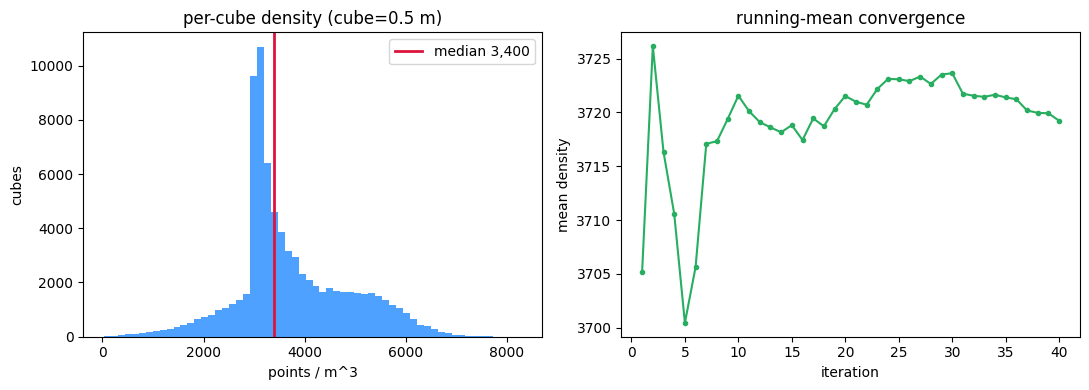

In [2]:
from scipy.spatial import cKDTree

CUBE_M    = 0.5     # probing cube side length [m]
N_CENTERS = 2000    # random centers per iteration
N_ITERS   = 40      # independent iterations (precision / stability)

las = laspy.read(REAL_LAS)
pts_real = np.vstack([las.x, las.y, las.z]).T.astype(np.float64)
print(f"real cloud: {len(pts_real):,} pts | extent {np.round(pts_real.max(0)-pts_real.min(0),2)} m")

tree     = cKDTree(pts_real)
half     = CUBE_M / 2.0
cube_vol = CUBE_M ** 3

per_cube, running_mean = [], []
for _ in range(N_ITERS):
    idx     = RNG.choice(len(pts_real), size=N_CENTERS, replace=False)
    counts  = tree.query_ball_point(pts_real[idx], r=half, p=np.inf, return_length=True)
    per_cube.append(counts / cube_vol)            # points per m^3
    running_mean.append(np.concatenate(per_cube).mean())

per_cube = np.concatenate(per_cube)
DENSITY  = float(np.median(per_cube))
print(f"density: median={DENSITY:,.0f}  mean={per_cube.mean():,.0f}  std={per_cube.std():,.0f}  pts/m^3")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(per_cube, bins=60, color="#4ea1ff")
ax[0].axvline(DENSITY, color="crimson", lw=2, label=f"median {DENSITY:,.0f}")
ax[0].set(title=f"per-cube density (cube={CUBE_M} m)", xlabel="points / m^3", ylabel="cubes")
ax[0].legend()
ax[1].plot(range(1, N_ITERS + 1), running_mean, "-o", ms=3, color="#27ae60")
ax[1].set(title="running-mean convergence", xlabel="iteration", ylabel="mean density")
fig.tight_layout(); fig.savefig(os.path.join(IMG_DIR, "density_estimate.png"), dpi=130); plt.show()

## 2 · Build the known-volume synthetic cloud

A row of `N_UNITS` **spheres** (canopy balls), and **above each sphere a box**. Spacing is
chosen so nothing overlaps, hence:

$$V_\text{true} = N\big(\tfrac{4}{3}\pi R^3 + L_x L_y L_z\big)$$

We fill each solid uniformly at the density measured above.

In [3]:
def sample_sphere(n, r, center, rng):
    v = rng.normal(size=(n, 3)); v /= np.linalg.norm(v, axis=1, keepdims=True)
    rr = r * np.cbrt(rng.random(n))               # uniform in volume
    return v * rr[:, None] + np.asarray(center)

def sample_box(n, dims, center, rng):
    return (rng.random((n, 3)) - 0.5) * np.asarray(dims, float) + np.asarray(center)

def vol_sphere(r):    return 4.0 / 3.0 * np.pi * r ** 3
def vol_box(dims):    d = np.asarray(dims, float); return float(d[0] * d[1] * d[2])

# --- scene definition (edit freely; e.g. SPHERE_R=2.0 for the example in the brief) ---
N_UNITS  = 10
SPHERE_R = 0.50
ROW_DY   = 1.50                 # center spacing along the row
BOX_DIMS = (0.60, 0.60, 0.80)   # Lx, Ly, Lz of the box above each sphere
BOX_GAP  = 0.10                 # clearance: sphere top -> box bottom

assert ROW_DY > 2 * SPHERE_R, "spheres overlap -> true volume not exact"
assert ROW_DY > BOX_DIMS[1],  "boxes overlap along the row"

unit_gt  = vol_sphere(SPHERE_R) + vol_box(BOX_DIMS)
GT_TOTAL = N_UNITS * unit_gt

# keep the cloud manageable
MAX_POINTS   = 1_500_000
DENSITY_USED = DENSITY
if GT_TOTAL * DENSITY > MAX_POINTS:
    DENSITY_USED = MAX_POINTS / GT_TOTAL
    print(f"capping density {DENSITY:,.0f} -> {DENSITY_USED:,.0f} pts/m^3 (<= {MAX_POINTS:,} pts)")

sphere_z = 0.0
box_cz   = sphere_z + SPHERE_R + BOX_GAP + BOX_DIMS[2] / 2.0
parts, labels = [], []
for i in range(N_UNITS):
    cy = i * ROW_DY
    ns = max(50, int(round(vol_sphere(SPHERE_R) * DENSITY_USED)))
    nb = max(50, int(round(vol_box(BOX_DIMS)    * DENSITY_USED)))
    parts.append(sample_sphere(ns, SPHERE_R, (0.0, cy, sphere_z), RNG)); labels += [f"sph{i}"] * ns
    parts.append(sample_box(nb, BOX_DIMS,    (0.0, cy, box_cz),   RNG)); labels += [f"box{i}"] * nb

syn    = np.vstack(parts)
labels = np.array(labels)
print(f"synthetic points : {len(syn):,}  ({N_UNITS} units)")
print(f"per-unit true vol: {unit_gt:.4f} m^3  ->  TRUE TOTAL = {GT_TOTAL:.4f} m^3")
print(f"realized density : {len(syn)/GT_TOTAL:,.0f} pts/m^3 (target {DENSITY_USED:,.0f})")

synthetic points : 27,590  (10 units)
per-unit true vol: 0.8116 m^3  ->  TRUE TOTAL = 8.1160 m^3
realized density : 3,399 pts/m^3 (target 3,400)


In [4]:
import plotly.graph_objects as go

m = syn if len(syn) <= 150_000 else syn[RNG.choice(len(syn), 150_000, replace=False)]
fig = go.Figure(go.Scatter3d(
    x=m[:, 0], y=m[:, 1], z=m[:, 2], mode="markers",
    marker=dict(size=1.4, color=m[:, 2], colorscale="Viridis")))
fig.update_layout(scene=dict(aspectmode="data"), height=620,
                  title=f"Synthetic vineyard row — TRUE volume = {GT_TOTAL:.3f} m^3")
fig.show()

## 3 · Voxelization estimator vs. true volume

Sweep the voxel edge `s`. We expect a sweet spot: too fine and surface/empty interior
hurts occupancy stability; too coarse and the cube discretization over-counts the volume.

voxel best: s=0.092 m  V=8.463 m^3  err=+4.3%


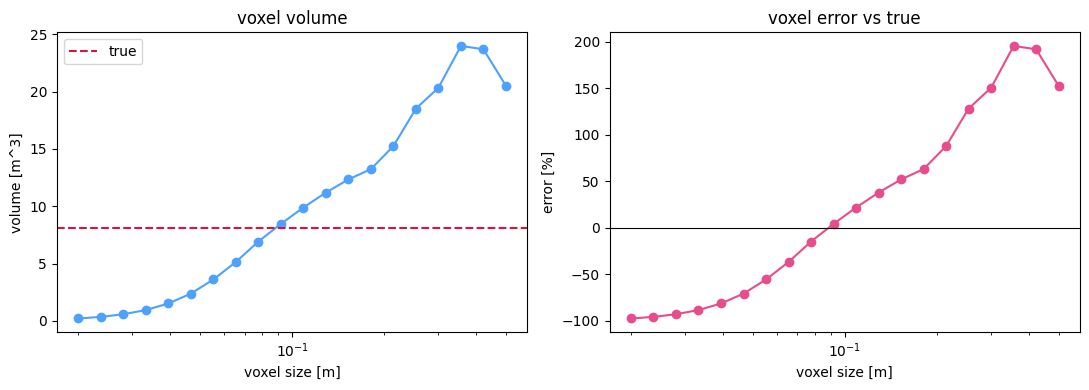

In [5]:
voxel_sizes = np.geomspace(0.02, 0.50, 20)
vox_vol = np.array([compute_voxel_volume(syn, float(s))["vol_voxel"] for s in voxel_sizes])
vox_err = (vox_vol - GT_TOTAL) / GT_TOTAL * 100.0

vb = int(np.argmin(np.abs(vox_err)))
print(f"voxel best: s={voxel_sizes[vb]:.3f} m  V={vox_vol[vb]:.3f} m^3  err={vox_err[vb]:+.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(voxel_sizes, vox_vol, "-o", color="#4ea1ff")
ax[0].axhline(GT_TOTAL, color="crimson", ls="--", label="true")
ax[0].set(xscale="log", xlabel="voxel size [m]", ylabel="volume [m^3]", title="voxel volume"); ax[0].legend()
ax[1].plot(voxel_sizes, vox_err, "-o", color="#e74c8c"); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xscale="log", xlabel="voxel size [m]", ylabel="error [%]", title="voxel error vs true")
fig.tight_layout(); fig.savefig(os.path.join(IMG_DIR, "voxel_sweep.png"), dpi=130); plt.show()

## 4 · Slice + alpha-shape estimator vs. true volume

Sweep the alpha radius `rmax`. Too small and the concave hull fragments (under-estimate);
too large and it bridges the gaps between objects in a slice (over-estimate).

alpha best: rmax=0.428 m  V=8.297 m^3  err=+2.2%


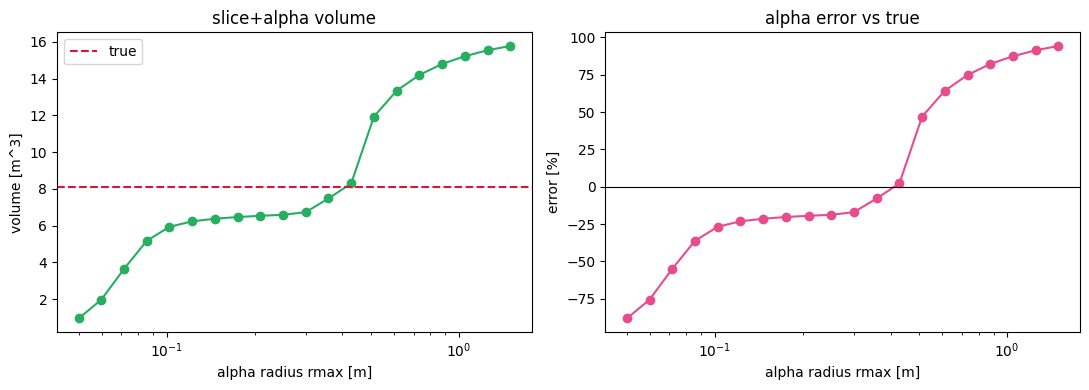

In [6]:
rmax_vals = np.geomspace(0.05, 1.50, 20)
slc_vol = np.array([compute_slice_volume(syn, n_slices=40, rmax=float(r))["vol_slice"] for r in rmax_vals])
slc_err = (slc_vol - GT_TOTAL) / GT_TOTAL * 100.0

sb = int(np.argmin(np.abs(slc_err)))
print(f"alpha best: rmax={rmax_vals[sb]:.3f} m  V={slc_vol[sb]:.3f} m^3  err={slc_err[sb]:+.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(rmax_vals, slc_vol, "-o", color="#27ae60")
ax[0].axhline(GT_TOTAL, color="crimson", ls="--", label="true")
ax[0].set(xscale="log", xlabel="alpha radius rmax [m]", ylabel="volume [m^3]", title="slice+alpha volume"); ax[0].legend()
ax[1].plot(rmax_vals, slc_err, "-o", color="#e74c8c"); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xscale="log", xlabel="alpha radius rmax [m]", ylabel="error [%]", title="alpha error vs true")
fig.tight_layout(); fig.savefig(os.path.join(IMG_DIR, "alpha_sweep.png"), dpi=130); plt.show()

## 5 · Summary

In [7]:
import pandas as pd
summary = pd.DataFrame([
 {"method": "voxelization", "best_param": f"s={voxel_sizes[vb]:.3f} m",
  "volume_m3": round(float(vox_vol[vb]), 3), "true_m3": round(GT_TOTAL, 3),
  "signed_err_%": round(float(vox_err[vb]), 2), "abs_err_%": round(abs(float(vox_err[vb])), 2)},
 {"method": "slice+alpha", "best_param": f"rmax={rmax_vals[sb]:.3f} m",
  "volume_m3": round(float(slc_vol[sb]), 3), "true_m3": round(GT_TOTAL, 3),
  "signed_err_%": round(float(slc_err[sb]), 2), "abs_err_%": round(abs(float(slc_err[sb])), 2)},
])
summary.to_csv(os.path.join(IMG_DIR, "summary.csv"), index=False)
print("saved:", os.path.join(IMG_DIR, "summary.csv"))
summary

saved: /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/images/synthetic_validation/summary.csv


,method,best_param,volume_m3,true_m3,signed_err_%,abs_err_%
0,voxelization,s=0.092 m,8.463,8.116,4.27,4.27
1,slice+alpha,rmax=0.428 m,8.297,8.116,2.23,2.23
